In [1]:
import requests
import io
import pandas as pd
import plotly as pl
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv(r"C:\Users\parja\OneDrive\Desktop\DATASETS\automobile_sales.csv")

# Print confirmation
print('Data downloaded and read into a dataframe!')

# Optional: Show the first few rows of the dataframe
print(df.head())

Data downloaded and read into a dataframe!
         Date  Year Month  Recession  Consumer_Confidence  Seasonality_Weight  \
0  1980-01-31  1980   Jan          1               108.24                0.45   
1  1980-01-31  1980   Jan          1               108.24                0.45   
2  1980-01-31  1980   Jan          1               108.24                0.36   
3  1980-01-31  1980   Jan          1               108.24                0.38   
4  1980-02-29  1980   Feb          1                98.75                0.46   

   Price  Advertising_Expenditure  Competition    GDP  Growth_Rate  \
0  27704                   1417.5            7  60.22         0.01   
1  77270                    763.7            7  60.22         0.01   
2  19665                   1417.5            7  60.22         0.01   
3  36986                   1417.5            7  60.22         0.01   
4  26609                   2773.4            4  45.99        -0.31   

   unemployment_rate  Automobile_Sales     Vehicl

In [2]:
df.describe()

,Year,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales
count,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000
mean,2001.520833,0.224432,101.210890,0.737756,41469.506155,2879.743655,6.118845,40.205748,-0.237074,2.441525,3164.160511
std,12.535031,0.417306,10.634092,0.286092,21388.409141,1175.338324,1.964292,16.291271,0.859691,1.108472,3640.137399
min,1980.000000,0.000000,73.900000,0.250000,15001.000000,494.200000,3.000000,12.510000,-4.230000,1.000000,40.000000
25%,1991.000000,0.000000,94.060000,0.500000,22039.000000,1872.000000,4.000000,27.210000,-0.570000,1.600000,923.000000
50%,2002.000000,0.000000,100.800000,0.810000,34957.500000,2883.500000,6.000000,39.420000,-0.005000,2.300000,2381.500000
75%,2012.000000,0.000000,108.320000,0.940000,57418.250000,3902.425000,8.000000,53.862500,0.392500,2.900000,4363.500000
max,2023.000000,1.000000,131.670000,1.500000,79998.000000,4983.000000,9.000000,70.370000,0.820000,6.000000,65645.000000


In [3]:
df.columns

Index(['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence',
       'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition',
       'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales',
       'Vehicle_Type', 'City'],
      dtype='str')

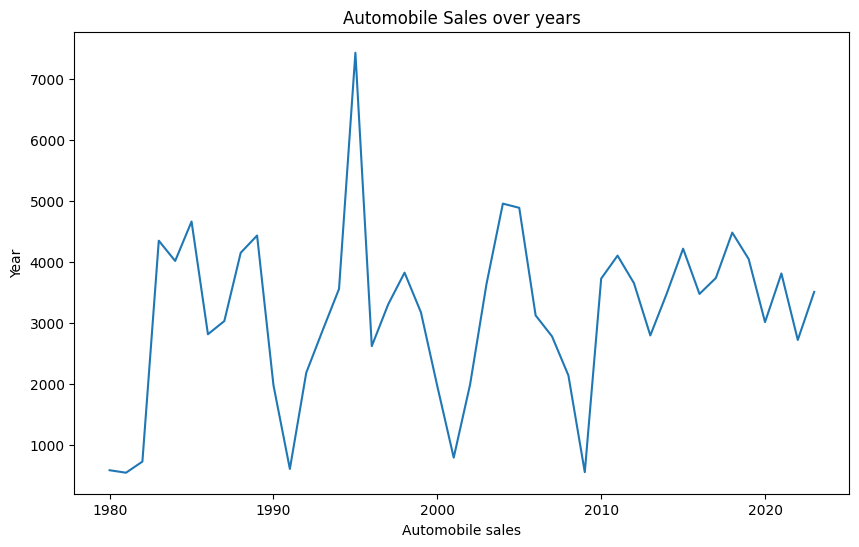

In [4]:
df_line = df.groupby(df['Year'])['Automobile_Sales'].mean()
#creating figure
plt.figure(figsize=(10, 6))
df_line.plot(kind = 'line')
plt.xlabel('Automobile sales')
plt.ylabel('Year')
plt.title('Automobile Sales over years')
plt.show()

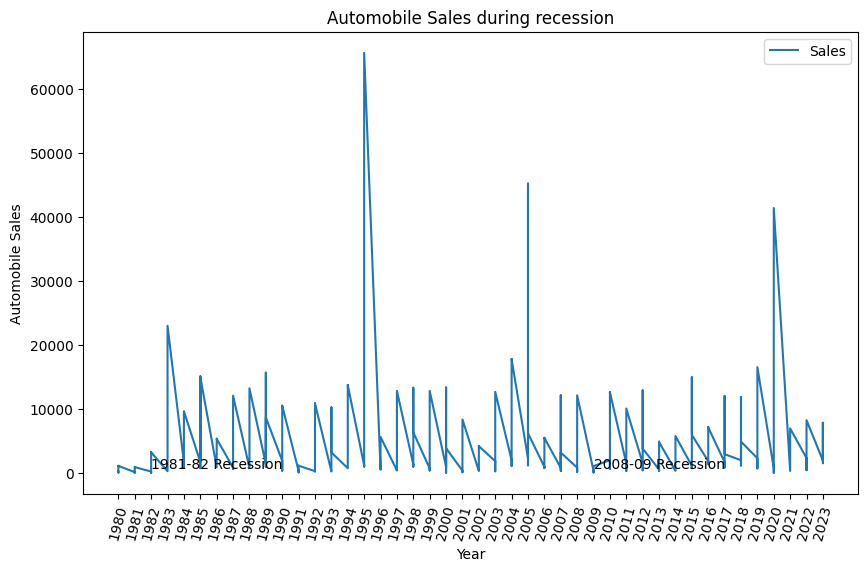

In [5]:
plt.figure(figsize=(10, 6))

# Select relevant columns
df_line = df[['Year', 'Automobile_Sales']]

# Plot
plt.plot(df_line['Year'], df_line['Automobile_Sales'])

# X ticks (all years)
plt.xticks(list(range(1980, 2024)), rotation=75)

# Labels
plt.xlabel('Year')
plt.ylabel('Automobile Sales')

# Title
plt.title('Automobile Sales during recession')

# Annotations (2 recession periods)
plt.text(1982, 650, '1981-82 Recession')
plt.text(2009, 650, '2008-09 Recession')

# Legend
plt.legend(['Sales'])

plt.show()

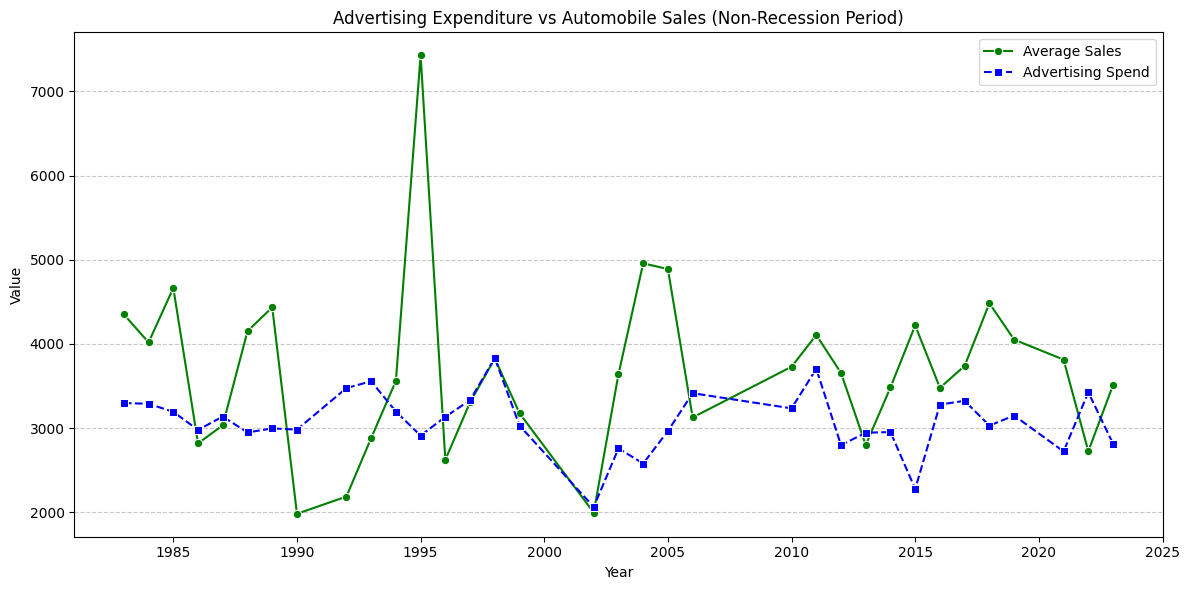

In [9]:

df_non_rec = df[df['Recession'] == 0]


df_trends = df_non_rec.groupby('Year', as_index=False).agg(
    Avg_Sales=('Automobile_Sales', 'mean'),
    Avg_Ad_Spend=('Advertising_Expenditure', 'mean')
)


plt.figure(figsize=(12, 6))

sns.lineplot(data=df_trends, x='Year', y='Avg_Sales',
             marker='o', linestyle='-', color='green', label='Average Sales')

sns.lineplot(data=df_trends, x='Year', y='Avg_Ad_Spend',
             marker='s', linestyle='--', color='blue', label='Advertising Spend')


plt.xlabel('Year')
plt.ylabel('Value')
plt.title('Advertising Expenditure vs Automobile Sales (Non-Recession Period)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

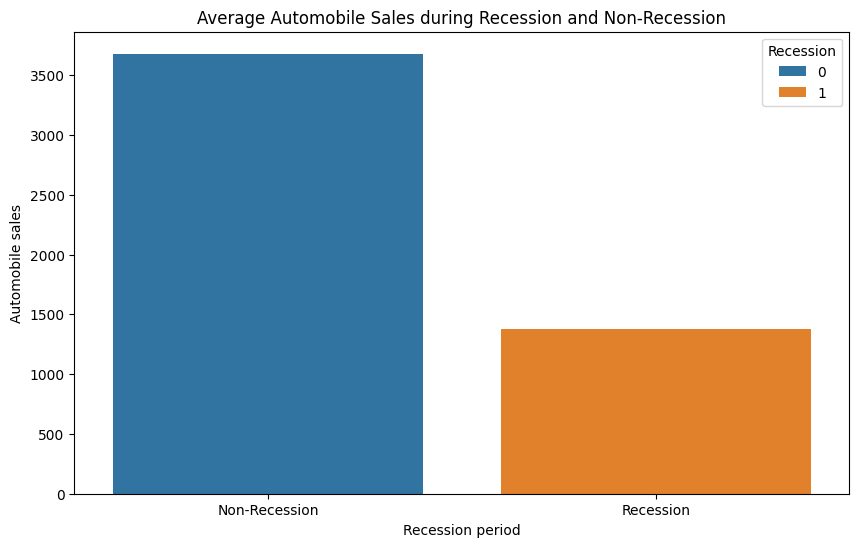

In [10]:
new_df = df.groupby('Recession')['Automobile_Sales'].mean().reset_index()

   
plt.figure(figsize=(10,6))
sns.barplot(x='Recession', y='Automobile_Sales', hue='Recession',  data=new_df)
plt.xlabel('Recession period')
plt.ylabel('Automobile sales')
plt.title('Average Automobile Sales during Recession and Non-Recession')
plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])
plt.show()

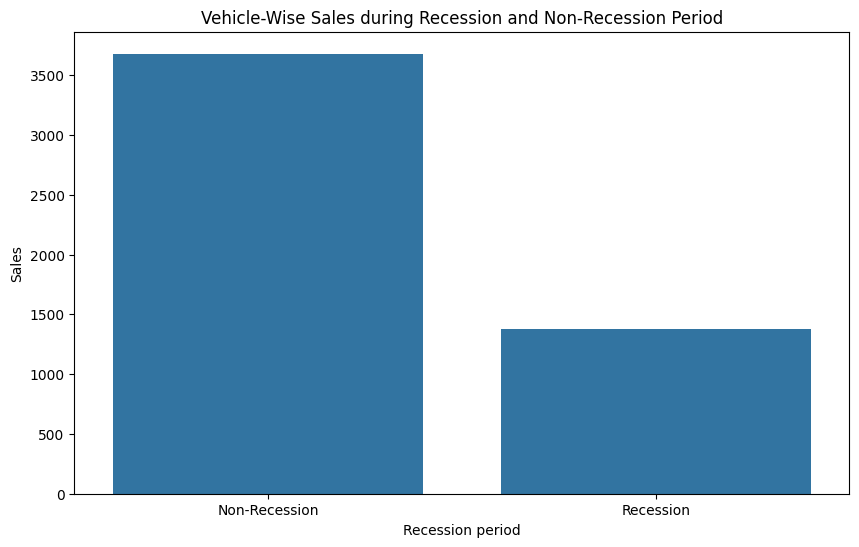

In [11]:
grouped_df = df.groupby('Recession')['Automobile_Sales'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Recession', y='Automobile_Sales', data=grouped_df)
plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])
plt.xlabel('Recession period')
plt.ylabel('Sales')
plt.title('Vehicle-Wise Sales during Recession and Non-Recession Period')

plt.show()

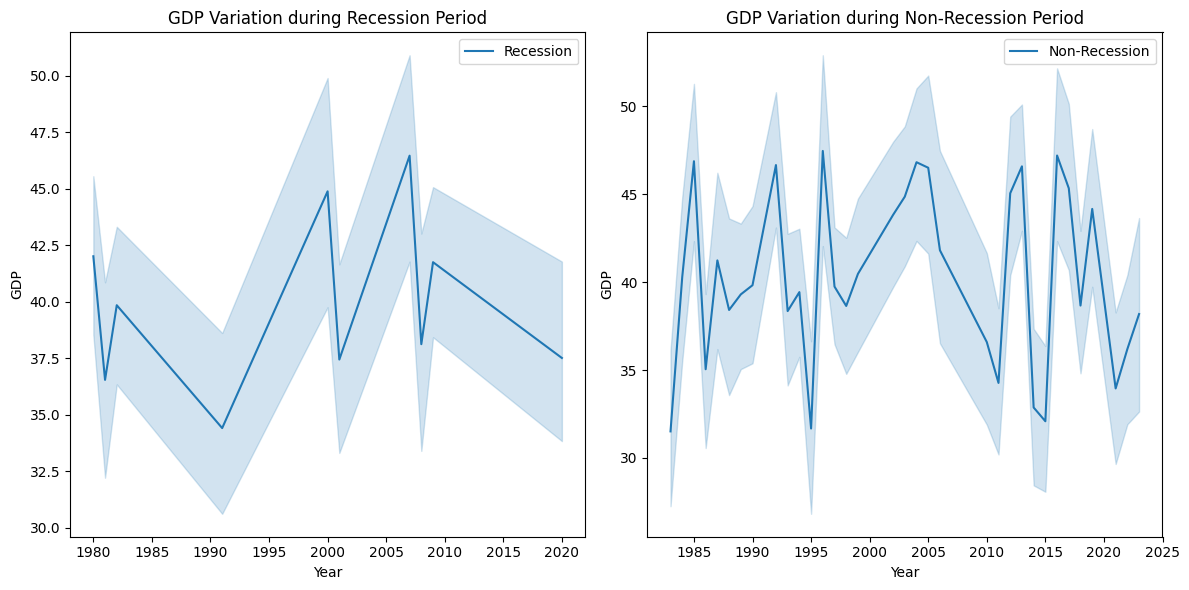

In [12]:

rec_data = df[df['Recession'] == 1]
non_rec_data = df[df['Recession'] == 0]


fig = plt.figure(figsize=(12, 6))


ax0 = fig.add_subplot(1, 2, 1)
ax1 = fig.add_subplot(1, 2, 2)


sns.lineplot(x='Year', y='GDP', data=rec_data, label='Recession', ax=ax0)
ax0.set_xlabel('Year')
ax0.set_ylabel('GDP')
ax0.set_title('GDP Variation during Recession Period')


sns.lineplot(x='Year', y='GDP', data=non_rec_data, label='Non-Recession', ax=ax1)
ax1.set_xlabel('Year')
ax1.set_ylabel('GDP')
ax1.set_title('GDP Variation during Non-Recession Period')

plt.tight_layout()
plt.show()

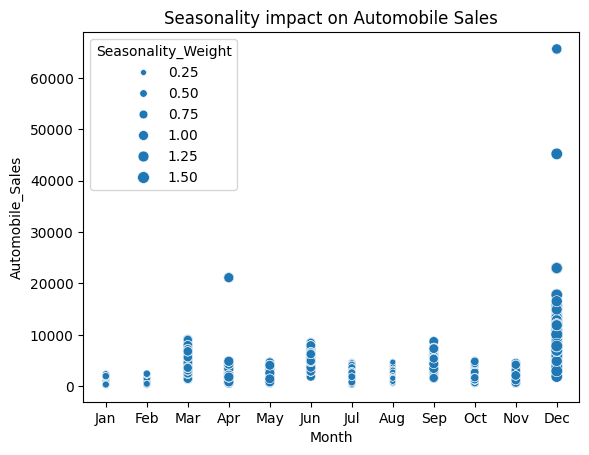

In [13]:
non_rec_data = df[df['Recession'] == 0]
    
size=non_rec_data['Seasonality_Weight']
    
sns.scatterplot(data=non_rec_data, x='Month', y='Automobile_Sales', size=size)
    
   

plt.xlabel('Month')
plt.ylabel('Automobile_Sales')
plt.title('Seasonality impact on Automobile Sales')

plt.show()

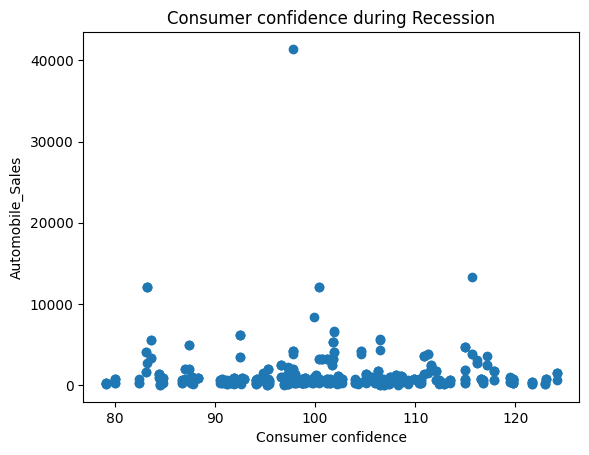

In [14]:
rec_data = df[df['Recession'] == 1]
plt.scatter(rec_data['Consumer_Confidence'], rec_data['Automobile_Sales'])
    
plt.xlabel('Consumer confidence')
plt.ylabel('Automobile_Sales')
plt.title('Consumer confidence during Recession')
plt.show()

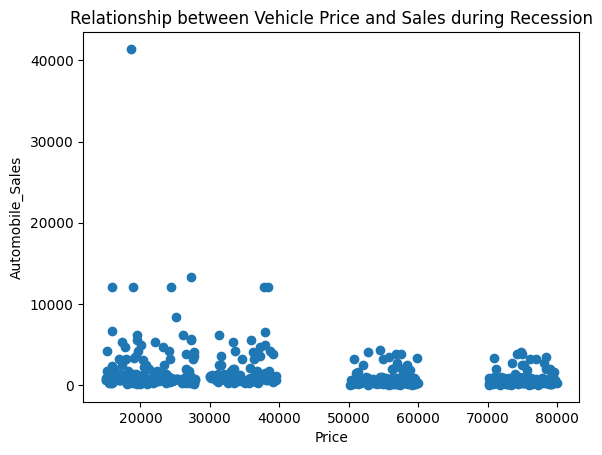

In [15]:
rec_data = df[df['Recession'] == 1]
plt.scatter(rec_data['Price'], rec_data['Automobile_Sales'])
    
plt.xlabel('Price')
plt.ylabel('Automobile_Sales')
plt.title('Relationship between Vehicle Price and Sales during Recession')
plt.show()

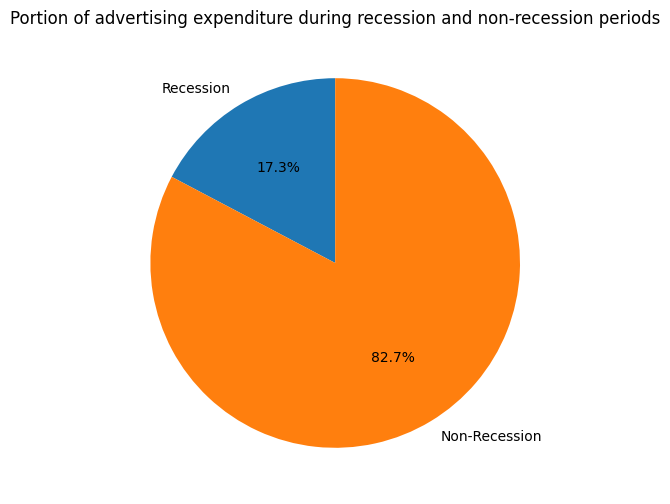

In [16]:
Rdata = df[df['Recession'] == 1]
NRdata = df[df['Recession'] == 0]

   
RAtotal = Rdata['Advertising_Expenditure'].sum()
NRAtotal = NRdata['Advertising_Expenditure'].sum()

     
plt.figure(figsize=(8, 6))

labels = ['Recession', 'Non-Recession']
sizes = [RAtotal, NRAtotal]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)

plt.title('Portion of advertising expenditure during recession and non-recession periods')

plt.show()

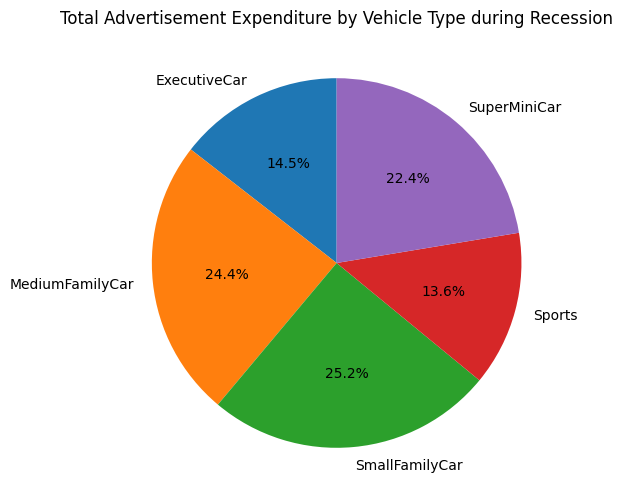

In [18]:
Rdata = df[df['Recession'] == 1]


VTexpenditure = Rdata.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()


plt.figure(figsize=(8, 6))

labels = VTexpenditure.index
sizes = VTexpenditure.values

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)

plt.title('Total Advertisement Expenditure by Vehicle Type during Recession')

plt.show()

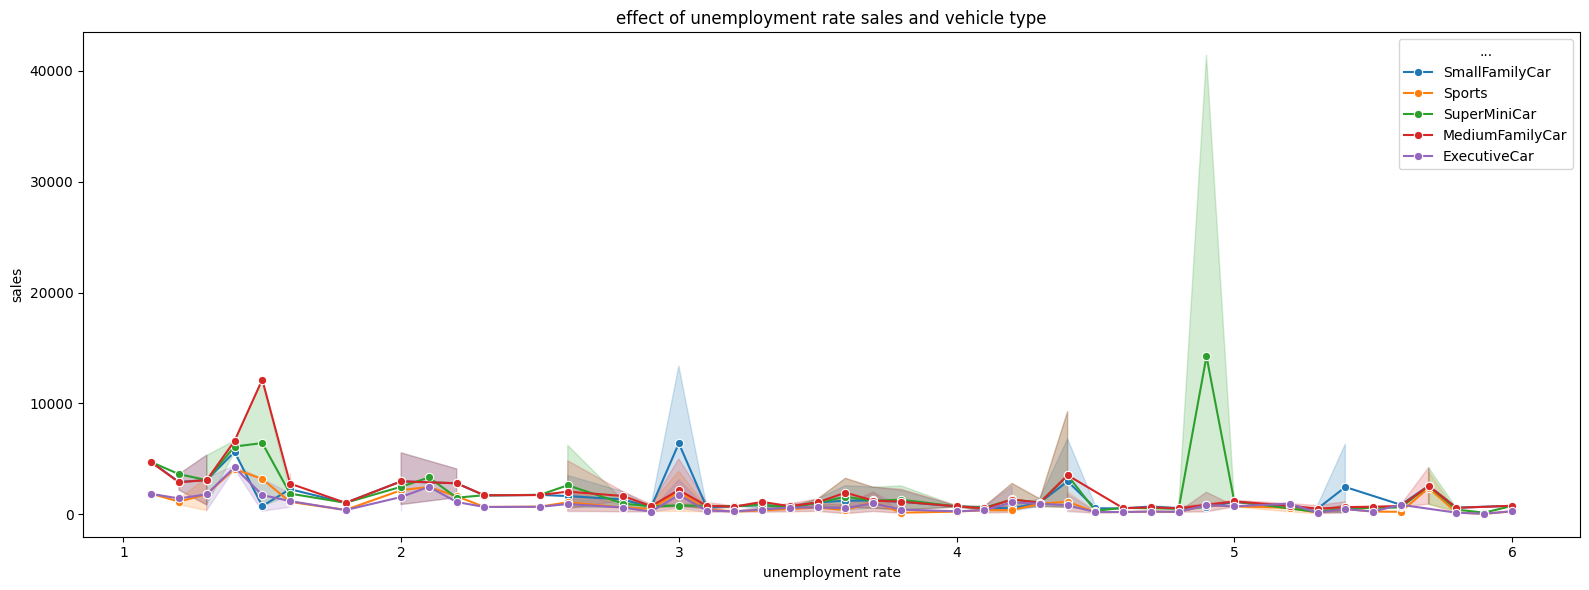

In [19]:
df_rec = df[df['Recession'] == 1]


plt.figure(figsize=(16, 6))


sns.lineplot(
    data=df_rec,
    x='unemployment_rate',             
    y='Automobile_Sales',             
    hue='Vehicle_Type',            
    marker='o'
)


plt.title('effect of unemployment rate sales and vehicle type')
plt.xlabel('unemployment rate')
plt.ylabel('sales')
plt.legend(title='...')


plt.tight_layout()
plt.show()